In [1]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add

import anthropic

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, make_message_langchain_compatible, make_message_anthropic_compatible
from dotenv import load_dotenv
import os
import voyageai

/Users/pranjal/Desktop/projects/AI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY")
voyageai_client = voyageai.Client(api_key=VOYAGE_API_KEY)
qdrant_client = QdrantClient(url="http://localhost:6333")

### Tools: Retrieval Tool

In [3]:
@traceable(
        name="embed_query",
        run_type="embedding",
        metadata={"ls_provider": "voyageai", "ls_model_name": "voyage-3"},
)
def get_embedding(voyageai_client, text, model = 'voyage-3'):
        result = voyageai_client.embed(
                [text],
                model=model,
                input_type="document"
        )

        # add metadata to langsmith obervability
        current_run = get_current_run_tree()
        if current_run:
                current_run.metadata["usage_metadata"] = {
                        "total_tokens": result.__dict__['total_tokens'],
                }

        return result.embeddings[0]

@traceable(
        name="retrieve_data",
        run_type="retriever",
)
def retrieve_data(query, k=5):
        query_embedding = get_embedding(voyageai_client, query)
        results = qdrant_client.query_points(
                collection_name="Amazon-items-collection-01-hybrid-search",
                prefetch=[
                        Prefetch(
                                query=query_embedding,
                                using='voyage-3',
                                limit=10,
                        ),
                        Prefetch(
                                query=Document(
                                        text=query,
                                        model="qdrant/bm25"
                                ),
                                using='bm25',
                                limit=10,
                        ),
                ],
                query=FusionQuery(fusion='rrf'), #reciprocal rank fusion
                limit=k,
        )

        retrieved_context_ids = []
        retrieved_context = []
        similarity_scores = []
        retrieved_context_ratings = []

        for item in results.points:
                retrieved_context_ids.append(item.payload['parent_asin'])
                retrieved_context.append(item.payload['description'])
                retrieved_context_ratings.append(item.payload['average_rating'])
                similarity_scores.append(item.score)
        
        return {
                "retrieved_context_ids": retrieved_context_ids,
                "retrieved_context": retrieved_context,
                "retrieved_context_ratings": retrieved_context_ratings,
                "similarity_scores": similarity_scores,
        }

@traceable(
        name="format_retrieved_context",
        run_type="prompt",
)
def process_context(context):
        formatted_context = ""
        for id, chunk, rating in zip(context['retrieved_context_ids'], context['retrieved_context'], context['retrieved_context_ratings']):
                formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        return formatted_context


def get_formatted_context(query: str, top_k: int = 5) -> str:
        """
        Get the top k context, each representing an inventory item for a given query.

        Args:
                query: The query to get the top k context for
                top_k: The number of context chunks to retrieve, works best with 5 or more

        Returns:
                A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.
        """

        context = retrieve_data(query, top_k)
        formatted_context = process_context(context)
        return formatted_context

### State and Pydantic models for Structured Output

In [4]:
class RAGUsedContext(BaseModel):
        id: str = Field(description="The ID of the item used to answer the question")
        description: str = Field(description="Short description of the item used to answe the question")


class ToolCall(BaseModel):
        name: str
        aruguments: dict

class AgentResponse(BaseModel):
        tool_calls: List[ToolCall] = []
        answer: str = Field(default="", description="Answer to the user's question based on current knowledge and tool results")
        final_answer: bool = Field(default=False, description="True if you have all information needed to provide a complete answer, False otherwise")
        references: List[RAGUsedContext] = Field(default=[], description="Items from retrieved context used to compile the answer")

"""
messages: Tool use come back as messages of type tool, used by agent to know if it has retrieved all of the info for answer
question_relevant: we will be using intent router node for query relevancy
iteration: no of times agent runs
answer:
available_tools: list of tools, defining what all tools we have in properly formatted dictionary format having docstring, args, return information for context to LLM
tool_calls: List of tool call for react agent to call tool in next step
final_answer: agent sets it to True if agent thinks it can answer the question from the context
references: which items were actually used?
"""
class  State(BaseModel):
        messages: Annotated[List[Any], add] = []
        question_relevant: bool = False
        iteration: int = 0
        answer: str = ""
        available_tools: List[Dict[str, Any]] = []
        tool_calls: List[ToolCall] = []
        final_answer: bool = False
        references: Annotated[List[RAGUsedContext], add] = []

In [5]:
@traceable(
name="agent_node",
run_type="llm",
metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"}
)
def agent_node(state: State) -> dict:

        prompt_template = """
        You are a shopping assistant that can answer questions about the products in stock.

        You will be given a conversation history and a list of tools you can use to answer the latest query.

        <Available tools>
        {{ available_tools | tojson }}
        </Available tools>

        When making tool calls, use this exact format:
        {
        "name": "tool_name",
                "arguments": {
                        "parameter1": "value1",
                        "parameter2": "value2",
                }
        }

        CRITICAL: All parameters must go inside the "arguments" object, not at the top level of the tool call.

        Examples:
        - Get formatted item context:
        {
                "name": "get_formatted_item_context",
                "arguments": {
                        "query": "Kool kids toys.",
                        "top_k": 5
                }
        }

        CRITICAL RULES:
        - If tool_calls has values, final_answer MUST be false (You cannot call tools and exit the graph in the same response)
        - If final_answer is true, tool_calls MUST be [] (You must wait for tool results before exiting the graph)
        - If you need tool results before answering, set: tool_calls=[...], final_answer=false
        - After receiving tool results, you can then set: tool_calls=[], final_answer=true
        - Use names specifically provided in the available tools. Don't add any additional text to the names.

        Instructions:
        - You need to answer the question based on the outputs from the tools using the available tools only.
        - Do not suggest the same tool call more than once.
        - If the question can be decomposed into multiple sub-questions, suggest all of them.
        - If multiple tool calls can be used at once to answer the question, suggest all of them.
        - Do not explain your next steps in the answer, instead use tools to answer the question.
        - Never use word context and refer to it as the available products.
        - You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.
        - As an output you need to return the following:

        * answer: The answer to the question based on your current knowledge and the tool results.
        * references: The list of the indexes from the chunks returned from all tool calls that were used to answer the question. If more than one chunk was used to compile the answer from a single tool call, be sure to return all of them.
        * Each reference should have an id and a short description of the item based on the retrieved context.
        * final_answer: True if you have all the information needed to provide a complete answer, False otherwise.
        - The answer to the question should contain detailed information about the product and should be returned with detailed specification in bullet points.
        - The short description should have the name of the item.
        - If the user's request requires using a tool, set tool_calls with the appropriate function names and arguments.
        """

        template = Template(prompt_template)
        prompt = template.render(
                available_tools=state.available_tools
        )

        conversation = make_message_anthropic_compatible(state.messages)

        if not conversation:
                conversation = [{"role": "user", "content": "Please assist with the query."}]

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AgentResponse,
                max_tokens=8096,
                system=prompt,
                messages=conversation,
                temperature=0.5,
        )

        ai_message = make_message_langchain_compatible(response)

        return {
                "messages": [ai_message], # toolNode from langchain require this (of langchain compatible type) to actually execute tool calls
                "tool_calls": response.tool_calls,
                "iteration": state.iteration + 1,
                "answer": response.answer,
                "final_answer": response.final_answer,
                "references": response.references
        }

### Tool router edge

In [6]:
def tool_router(state: State) -> str:
        """Decide wheater to continue or end"""
        if state.final_answer or state.iteration > 1:
                return "end"
        if len(state.tool_calls) > 0:
                return "tools"
        return "end"

### Intent Router Edge + Node

In [7]:

class IntentRouterResponse(BaseModel):
        question_relevant: bool
        answer: str


def intent_router_conditional_edge(state: State):
        if state.question_relevant:
                return "agent"
        else:
                return "end"

@traceable(
        name="intent_router_node",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def intent_router_node(state: State):

        prompt_template = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to clasify it into relevant or not relevant.
                - If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
                - If the question is relevant, return True in field "question_relevant" and set "answer" to "".
                - You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.
        """

        template = Template(prompt_template)

        prompt = template.render()

        messages = state.messages
        conversation = conversation = make_message_anthropic_compatible(state.messages)
        if not conversation:
                conversation = [{"role": "user", "content": "Please assist with the query."}]

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=IntentRouterResponse,
                max_tokens=8096,
                system=prompt,
                messages=conversation,
                temperature=0.5,
        )

        return {
                "question_relevant": response.question_relevant,
                "answer": response.answer
        }

### Graph

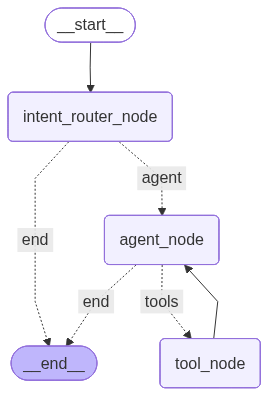

In [8]:
workflow = StateGraph(State)

tools = [get_formatted_context]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
        source = "intent_router_node",
        path = intent_router_conditional_edge,
        path_map = {
                "agent": "agent_node",
                "end": END,
        }
)
workflow.add_conditional_edges(
        source = "agent_node",
        path = tool_router,
        path_map = {
                "tools": "tool_node",
                "end": END,
        }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
initial_state = {
        "messages": [
                {"role": "user", "content": "Can I get earphone for me, laptop bag for my wife and something cool for my kids"},
        ],
        "available_tools": tool_descriptions
}
result = graph.invoke(initial_state)
result

{'messages': [{'role': 'user',
   'content': 'Can I get earphone for me, laptop bag for my wife and something cool for my kids'},
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'get_formatted_context', 'args': {'query': 'earphones', 'top_k': 5}, 'id': 'call_0', 'type': 'tool_call'}, {'name': 'get_formatted_context', 'args': {'query': 'laptop bag', 'top_k': 5}, 'id': 'call_1', 'type': 'tool_call'}, {'name': 'get_formatted_context', 'args': {'query': 'cool toys for kids', 'top_k': 5}, 'id': 'call_2', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content="- ID: B0BLSRBKY7, rating: 4.7, description: yobola Wireless Earbuds 10 Wireless Earbuds\n- ID: B0B1T59VHW, rating: 4.4, description: Wireless Earbud, Bluetooth 5.2 Headphones with ENC HD Mic, Bluetooth Earphones with Deep Bass, Bluetooth Earbud in Ear Noise Cancelling, 40H Wireless Headphones IP7 Ear Buds, White[2022 Upgrade] Upgraded Bluetoth 5.2 & Effortless Pairing: Ddidbi wirel